
## STOCHASTIC MODELING
MODULE 7 | LESSON 1


---

# **MONTE CARLO METHODS**

|  |  |
|:---|:---|
|**Reading Time** |  60 min |
|**Prior Knowledge** |Markov process, Optimization, Monte Carlo  |
|**Keywords** |Reinforcement learning, multi-armed bandits


---

*In this last module, we are going to combine many of the concepts we have covered in the previous modules. We are going to delve further into three relevant RL algorithms, Monte Carlo, SARSA, and Q-learning, that exploit the dynamic programming principles and simulation-based methods we explored in previous modules. In this lesson, we focus on Monte Carlo methods.*

In [1]:
import numpy as np
from numpy.random import rand, seed

## **1. Monte Carlo Methods**

We first consider Monte Carlo methods as a way to learn the state-value function for a given policy. Recall that the value of a state is the cumulative discounted future rewards starting from that state. An obvious way to estimate that function is from experience by averaging the returns observed after visits to that state. As the agent observes more realizations of the returns, the average should converge to the expected value.

The Monte Carlo methods learn value functions and optimal policies from experience in the form of sample episodes, as we devised in the previous module for the $k$-armed bandit problem. Even relative to dynamic programming methods, where we have complete knowledge of the environment, Monte Carlo methods that work with sample episodes alone can be a significant advantage. The main advantages of Monte Carlo methods are (i) the lack of an explicit model of transition probabilities and (ii) the outright focus on a small subset of the states that are relevant for the actions of the agents, without accurately evaluating the "uncharted" regions of the state set.


**Learning in the windy gridworld**

To introduce the RL algorithms in this module, we are going to revisit the gridworld problem we studied in Module 2. Recall that the agent's objective is to reach either of the terminal cells colored in gray in the figure below, where each transition generates a reward of -1. Movements can be up, down, right, or left, while any movement "out" of the grid keeps the agent in the same cell in the next time step.<span style='color: transparent; font-size:1%'>All rights reserved WQU WorldQuant University QQQQ</span>

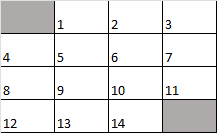

Let's build the model for transitions for this model.

In [2]:
N = 16
GRID_WIDTH = np.sqrt(N)
NROWS = int(N / GRID_WIDTH)
S_GRID = np.linspace(1, N - 2, N - 2)
A = 4

# Build an array that indicates, for each state, the destination cells
# from moving up, down, right, or left
destinations = np.zeros((N, A), dtype=np.int8)
destinations[N - 1, :] = (N - 1) * np.ones((A), dtype=np.int8)
for ss in range(1, N - 1):
    # determine row of position ss in the grid
    row_ss = np.floor(ss / GRID_WIDTH) + 1

    destinations[ss, 0] = (ss - GRID_WIDTH) * (ss - GRID_WIDTH >= 0) + ss * (
        ss - GRID_WIDTH < 0
    )
    destinations[ss, 1] = (ss + GRID_WIDTH) * (ss + GRID_WIDTH <= N - 1) + ss * (
        ss + GRID_WIDTH > N - 1
    )
    destinations[ss, 2] = (ss + 1) * (ss < row_ss * GRID_WIDTH - 1) + ss * (
        ss >= row_ss * GRID_WIDTH - 1
    )
    destinations[ss, 3] = (ss - 1) * (ss > (row_ss - 1) * GRID_WIDTH) + ss * (
        ss <= (row_ss - 1) * GRID_WIDTH
    )

print(destinations)

[[ 0  0  0  0]
 [ 1  5  2  0]
 [ 2  6  3  1]
 [ 3  7  3  2]
 [ 0  8  5  4]
 [ 1  9  6  4]
 [ 2 10  7  5]
 [ 3 11  7  6]
 [ 4 12  9  8]
 [ 5 13 10  8]
 [ 6 14 11  9]
 [ 7 15 11 10]
 [ 8 12 13 12]
 [ 9 13 14 12]
 [10 14 15 13]
 [15 15 15 15]]


Now we are going to slightly complicate the tasks of the agent in this model. Random gusts of wind are hitting the gridworld in a downward direction. These windy conditions are strongest in the "upper" part of the gridworld. That is, for each row of the gridworld, the agent will be moved downward from their current cell, regardless of the action taken by the agent. The probability will be higher in the uppermost part of the grid. We capture this assumption by defining the next array: 

In [3]:
# Set probability of down movement at each row

PDOWN = np.zeros((N))

PDOWN[0] = 0.8
PDOWN[1] = 0.4
PDOWN[2] = 0.2
PDOWN[3] = 0.1

With this setup, we are going to exploit the following function to determine the state in the following time step given some action and the effect of windy conditions:

In [4]:
def transition(state_init, action, dest, prdown, gridw, randnum):
    row_ss = np.floor(state_init / gridw)
    if randnum < prdown[int(row_ss)]:
        state_end = dest[int(state_init), 1]
    else:
        state_end = dest[int(state_init), action]
    return state_end

Monte Carlo methods rely on obtaining a record of histories across different "episodes" that, after averaging, allows for inferring the optimal value and policy functions of the agent. The agent will incrementally learn those functions as they gain experience and act according to that experience.

In the absence of a known model of the environment, it is particularly useful to estimate the values of state-action pairs, $Q(s,a)$ rather than state values $v(s)$. Thus, we are going to focus on $Q(s,a)$ as our main objective to optimize/estimate. Analogous with the policy iteration scheme we studied in Module 2, Monte Carlo methods first involve the computation of optimal state-action values for a given policy. We compute those values from repeated observations of the environment and then simply average the returns observed after visits to each state. As more returns are observed, the average should converge to the expected value. The second step consists of improving the policy given the state-action pairs involved. Repeating the two steps of the algorithm, we will reach the optimal objects.

Within an episode, each occurrence of state $s$ after taking action $a$ is called a visit to $(s,a)$. The pair $(s,a)$ may be visited multiple times in the same episode. "Every-visit" MC methods estimate the value of a state-action pair as the average of the rewards that have followed all the visits to it. "First-visit" MC methods average the rewards only following the first time in each episode that the state-action pair was visited and the action was selected. We can take both methods as essentially the same, though subject to some technicalities that we are going to ignore. 

Let's initialize the objects to optimize, policy and state-action function, and two arrays that at each episode will store the rewards obtained at each $(s,a)$ and the number of visits per $(s,a)$.

In [5]:
# Assume an initial policy that is random
policy = np.ones((N, A)) / A
qvalue = np.zeros((N, A))

# Array to fill with optimal action at each cell
policy0 = np.zeros((N))

# Initialize arrays of average rewards and number of visits per (s,a)
returns = np.zeros((N, A))
visits = np.zeros((N, A))

Many state-action pairs may never be visited by repeated experience. In the extreme case, a deterministic policy may not take some actions that are actually optimal, so we may have no experience to update the rewards from them. That is, we again face the exploration-exploitation trade-off. To overcome this issue, we can opt for "exploring starts" and also $\varepsilon$-greedy policies, as we studied in the previous module. 

The block of code below implements the "exploring starts" and $\varepsilon$-greedy policies that we are going to repeatedly exploit in the applications below:

In [6]:
def exploring_starts(nstates, randnum):
    for ss in range(nstates):
        if randnum < (ss + 1) / nstates:
            break
    return ss


def e_greedy_policy(nactions, pol, eps, randnum1, randnum2, randnum3):
    if randnum1 < eps:
        for aa in range(nactions):
            if randnum2 < (aa + 1) / A:
                break
    else:
        for aa in range(nactions):
            if randnum3 < np.cumsum(pol)[aa]:
                break
    return aa

For Monte Carlo policy evaluation, it is natural to alternate between evaluation and improvement on an episode-by-episode basis. Once we reach the end of an episode, the observed returns are used for policy evaluation, and then the policy is improved at all the states visited in the episode.

Below, we solve the model, using 5,000 episodes, each of which end after reaching either of the terminal states or after 100 movements. For exploration, we opt for "exploring starts," choosing at random the initial state, and a $\varepsilon$-greedy action choice. The iteration algorithm can be described in the following pseudo-code:

0. Initialize arrays of policies, $\Pi$, and state-action values, $Q$.
1. Loop over each episode. Choose random initial state, $s_0$:

  * Follow $\varepsilon$-greedy policy to determine action $a$, given $s_0$. Store visit to $(s_t,a_t)=(s_0,a)$, reward $r_t=r(s_0,a)$, and transition to next state $s_1$. Set $s_0 = s_1$ and iterate until the end of episode. 

  * Compute $G_t = r_t + \gamma G_{t+1}$. $G(s,a)$ records the value of the first visit, "first-visit" MC, or the average across all visits, "every-visit" MC, to the state-action pair.

  * Update average reward and state-action values: $Q(s,a) = Average[G(s,a)]$ across all previous episodes, for state-action pairs that have been visited in the episode.

  * Update the policy $\Pi(s)=\arg\underset{a}{\max}Q(s,a)$ and continue to next episode.

In one array, "history," we keep track of which state-action pairs are visited at each time step of the episode. In another array, `gfunc`, we store the value obtained at each time step of the episode. Recall that we assume that $\gamma=1$ in the gridworld model.

In [7]:
seed(1234)

# Monte Carlo method in windy gridworld
EPISODES = 5000
EPISODE_TMAX = 100
EPSILON = 0.1

# 1. Loop over episodes
for episode in range(EPISODES):
    qvalue_old = qvalue.copy()
    gfunc = np.zeros((EPISODE_TMAX))
    history = np.zeros((EPISODE_TMAX, 2), dtype=np.int8)
    # 1.1. Choose initial state
    ss0 = exploring_starts(N, rand())
    # Loop over each time step in the episode
    for tt in range(EPISODE_TMAX):
        # 1.2. Find optimal action given the current policy
        aa = e_greedy_policy(A, policy[int(ss0), :], EPSILON, rand(), rand(), rand())
        history[tt, :] = [int(ss0), aa]  # store state-action pair (s,a)
        # Determine which is the next state, given the action
        # and the probability of a downwards gust of wind
        tt_end = tt
        if ss0 < 1 or ss0 > N - 2:
            break
        ss0 = transition(ss0, aa, destinations, PDOWN, GRID_WIDTH, rand())
    # 1.3. Determine which is the value obtained at each time step on a backwards basis
    for tt in range(EPISODE_TMAX - 2, -1, -1):
        if history[tt, 0] > 0 and history[tt, 0] < N - 1:
            gfunc[tt] = -1 + gfunc[tt + 1]
    # Store first-visit value information
    state_mc = np.zeros((N, A))  # Stores if we have visited state-action pair (s,a)
    for tt in range(tt_end + 1):
        if (
            state_mc[history[tt, 0], history[tt, 1]] != 1
        ):  # Comment to make every-visit MC
            state_mc[history[tt, 0], history[tt, 1]] = 1
            returns[history[tt, 0], history[tt, 1]] += gfunc[tt]
            visits[history[tt, 0], history[tt, 1]] += 1
    # 1.4. Update the Q-function where the previous episode has gone through
    qvalue_new = np.divide(
        returns, visits, out=np.zeros_like(returns), where=visits != 0
    )
    qvalue = qvalue_new * (visits != 0) + qvalue_old * (visits == 0)
    # 1.5. Improve policy
    policy0 = np.argmax(qvalue, axis=1)
    policy = np.zeros((N, A))
    for ss in range(N):
        policy[ss, policy0[ss]] = 1.0

# Visits to each state-action
print(visits)
# State-action values
print(qvalue)
# Optimal policy at each cell
for rr in range(NROWS):
    print(policy0[rr * int(GRID_WIDTH) : rr * int(GRID_WIDTH) + int(GRID_WIDTH)])

[[ 381.   14.    6.   11.]
 [   9.   10.    7.  298.]
 [  12.   15.  288.   10.]
 [   9.  346.   14.   14.]
 [  82.   19.   25.  262.]
 [  20.  577.   21.   10.]
 [  15.   18.  579.   13.]
 [  34.  993.   22.   30.]
 [  11.   19.  592.   16.]
 [  40.   33. 1363.   43.]
 [  39.   48. 1572.   50.]
 [  55. 2476.   66.   71.]
 [  17.   11.  442.   21.]
 [  42.   44. 1105.   33.]
 [  51.   42. 1743.   61.]
 [4239.  121.  108.  117.]]
[[  0.           0.           0.           0.        ]
 [-18.33333333  -5.4         -5.71428571  -4.61073826]
 [-11.58333333  -7.86666667  -4.26388889  -5.6       ]
 [ -6.55555556  -3.21965318  -3.5         -5.57142857]
 [ -3.85365854 -10.47368421  -7.56        -6.73282443]
 [-10.45        -4.39168111  -8.47619048  -7.8       ]
 [-10.          -7.88888889  -3.28151986  -7.92307692]
 [ -4.52941176  -2.12084592  -2.72727273  -3.26666667]
 [-19.09090909 -14.          -4.54222973 -16.4375    ]
 [ -7.35        -5.          -3.34042553  -6.74418605]
 [ -5.94871795  -

Notice how the optimal movements in this gridworld are tilted "downwards." The windy gusts also greatly penalize the states that are far from the bottom terminal cell.

## **2. Conclusion**

In this lesson, we have worked through the Monte Carlo methods in reinforcement learning problems. In the next lesson, we will start covering temporal difference learning methods.

See you there!

---
Copyright 2023 WorldQuant University. This
content is licensed solely for personal use. Redistribution or
publication of this material is strictly prohibited.
